# Multimodal Classification — UPMC Food-101

This notebook is now **module-first**:
- `src/data_loader.py` handles data and metadata
- `src/eda.py` handles EDA
- `src/baselines.py` handles zero-shot and few-shot baselines
- `src/trainer.py` handles training the final multimodal head

The notebook only orchestrates the pipeline and visualizes outputs.

## 1. Setup

In [2]:
import importlib
import warnings
from pathlib import Path
import sys

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd

# Ensure package imports work no matter where the kernel cwd starts.
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "MultimodalClassification" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import MultimodalClassification.src.data_loader as data_loader
import MultimodalClassification.src.eda as eda
import MultimodalClassification.src.baselines as baselines
import MultimodalClassification.src.trainer as trainer
import MultimodalClassification.src.metrics as metrics
import MultimodalClassification.src.service as service_module

importlib.reload(data_loader)
importlib.reload(eda)
importlib.reload(baselines)
importlib.reload(trainer)
importlib.reload(metrics)
importlib.reload(service_module)

from MultimodalClassification.src.clip_utils import HF_CLIP_MODEL, get_device, load_frozen_clip
from MultimodalClassification.src.data_loader import get_food101_dataloaders
from MultimodalClassification.src.eda import (
    dataset_overview,
    multimodal_text_health_report,
    plot_class_distribution,
    plot_sample_gallery,
    plot_text_length_histograms,
    top_confused_pairs,
)
from MultimodalClassification.src.baselines import (
    build_results_table,
    evaluate_multimodal_zero_shot,
    run_few_shot_logreg,
)
from MultimodalClassification.src.trainer import CHECKPOINT_PATH, evaluate_head, train_model
from MultimodalClassification.src.metrics import classification_metrics, full_classification_report
from MultimodalClassification.src.service import MultimodalFoodClassifierService

DEVICE = get_device()
print("Device:", DEVICE)

Device: cuda


## 2. Load data

In [5]:
BATCH_SIZE = 32
VAL_RATIO = 0.10
SEED = 42

clip_bundle = load_frozen_clip(HF_CLIP_MODEL, device=DEVICE)

train_loader, val_loader, test_loader, CLASSES, class_to_idx, metadata = get_food101_dataloaders(
    batch_size=BATCH_SIZE,
    val_ratio=VAL_RATIO,
    seed=SEED,
    processor=clip_bundle.processor,
    return_test_loader=True,
    return_metadata=True,
)

idx_to_class = metadata.idx_to_class

print("Layout:", metadata.layout)
print("Num classes:", len(CLASSES))
print("Train samples:", len(metadata.train_df))
print("Test samples:", len(metadata.test_df))

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 12961.36it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[data_loader] Downloading 'gianmarco96/upmcfood101' via kagglehub …
[data_loader] Dataset cached at: /home/anhhuy/.cache/kagglehub/datasets/gianmarco96/upmcfood101/versions/1
[data_loader] Using pre-loaded CLIPProcessor.
[data_loader] layout=assignment1_csv | train=61175 | val=6797 | test=22716 | classes=101
Layout: assignment1_csv
Num classes: 101
Train samples: 67972
Test samples: 22716


## 3. EDA

In [3]:
overview = dataset_overview(metadata.train_df, metadata.test_df)
text_report = multimodal_text_health_report(metadata.train_df)

print("=== Dataset Overview ===")
for k, v in overview.items():
    print(f"{k}: {v}")

print("\n=== Text Health Report ===")
for k, v in text_report.items():
    print(f"{k}: {v}")

=== Dataset Overview ===
num_classes: 101
num_train_samples: 67972
num_test_samples: 22716
avg_train_samples_per_class: 672.990099009901
min_class: lobster_bisque
min_class_count: 591
max_class: macaroni_and_cheese
max_class_count: 713

=== Text Health Report ===
short_text_samples: 2653
short_text_ratio_pct: 3.903077737892073
char_mean: 50.58401989054317
char_median: 47.0
word_mean: 7.91718648855411
word_median: 7.0


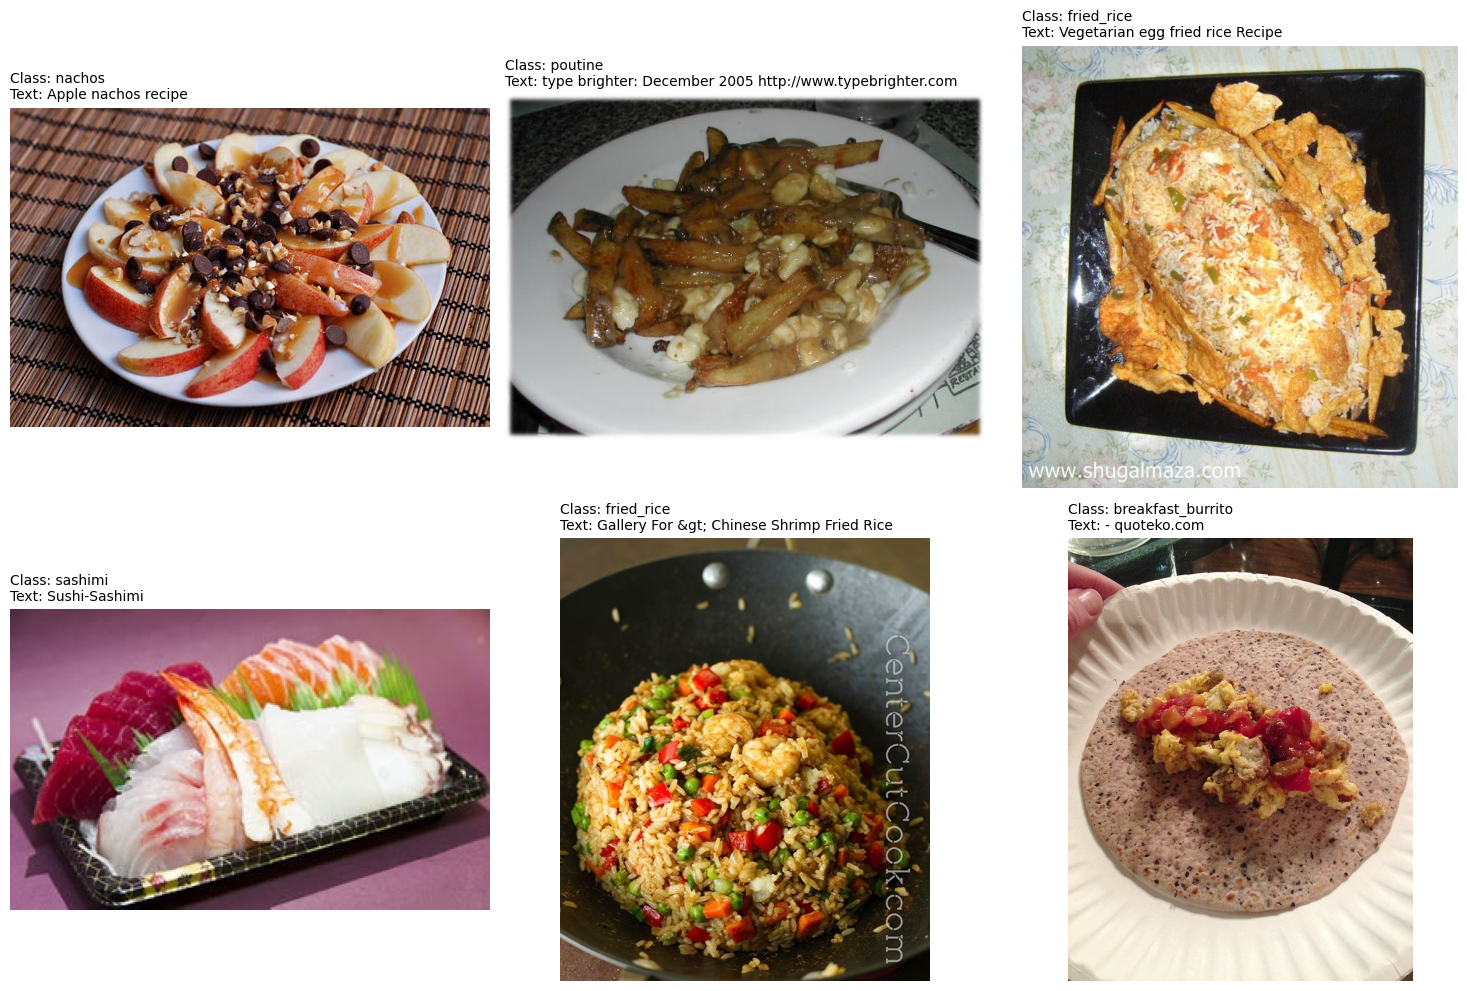

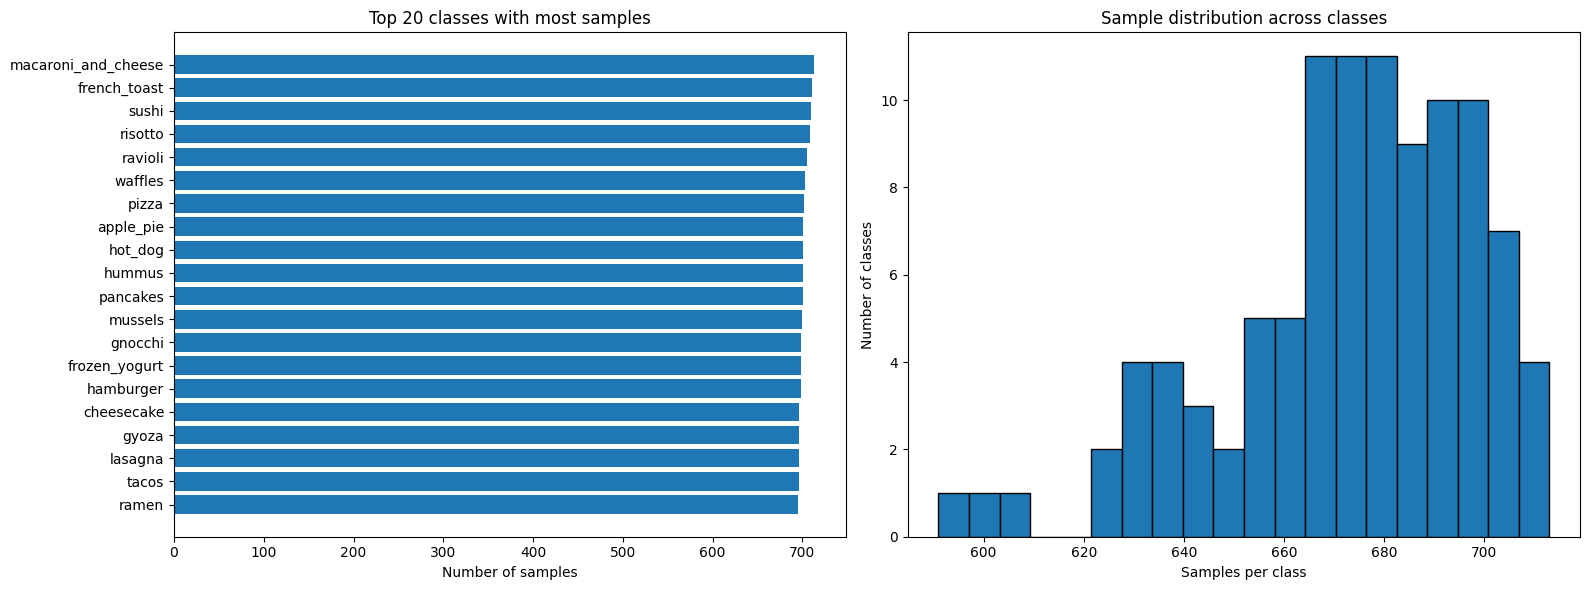

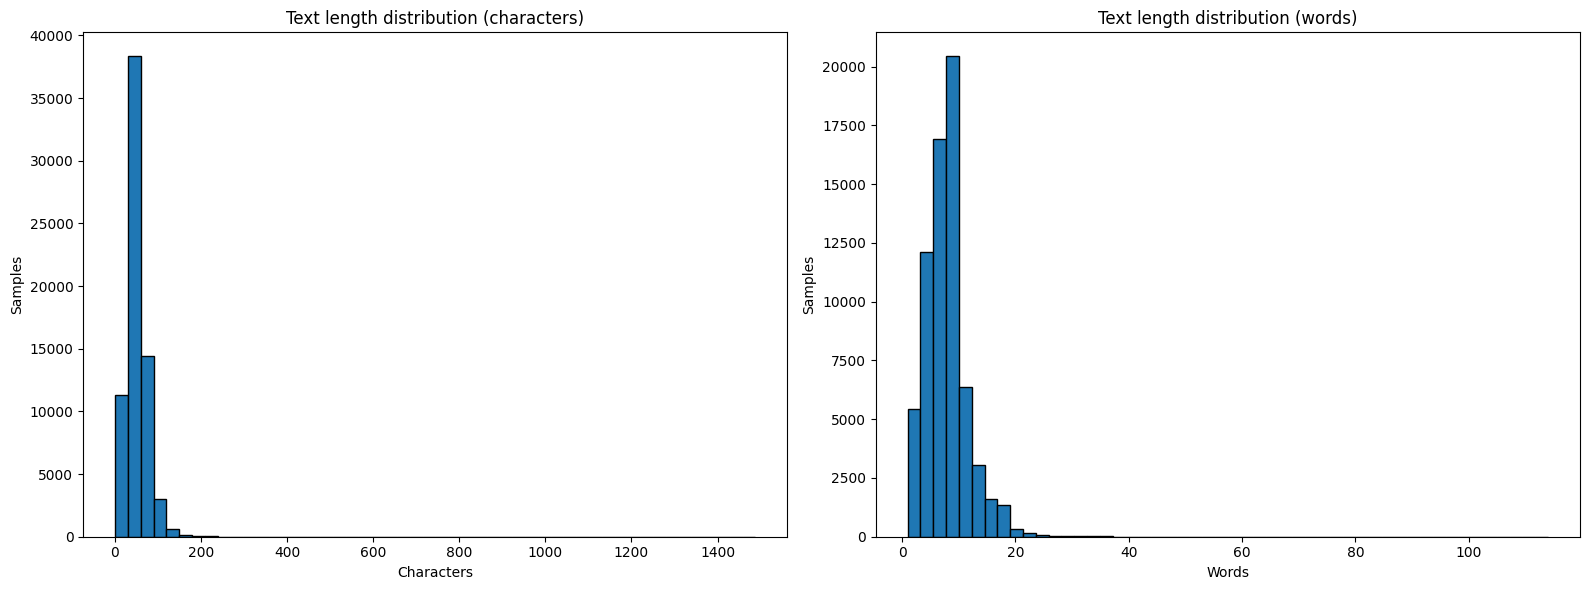

In [4]:
plot_sample_gallery(metadata.train_df, CLASSES, save_path="eda_sample_gallery.png")
plt.show()

plot_class_distribution(metadata.train_df, save_path="eda_class_distribution.png")
plt.show()

plot_text_length_histograms(metadata.train_df, save_path="eda_text_length_hist.png")
plt.show()

## 4. Zero-shot CLIP

In [7]:
ALPHA = 0.50

zs_preds, zs_labels, zs_metrics = evaluate_multimodal_zero_shot(
    loader=test_loader,
    classes=CLASSES,
    alpha=ALPHA,
    clip=clip_bundle,
)

print(zs_metrics)

Zero-shot multimodal eval: 100%|██████████| 710/710 [02:08<00:00,  5.51it/s]

{'accuracy': 0.8296354992076069, 'macro_f1': 0.8336751307856922, 'top5_accuracy': 0.9090508892410636, 'alpha': 0.5}


## 5. Few-shot CLIP embeddings + Logistic Regression

In [8]:
K_VALUES = [1, 5, 10]

few_shot_results = run_few_shot_logreg(
    train_df=metadata.train_df,
    test_loader=test_loader,
    processor=clip_bundle.processor,
    k_values=K_VALUES,
    seed=SEED,
    device=DEVICE,
    batch_size=BATCH_SIZE,
)

few_shot_summary = pd.DataFrame(
    [{
        "K": k,
        "Accuracy": few_shot_results[k].accuracy,
        "Macro-F1": few_shot_results[k].macro_f1
    } for k in K_VALUES]
)
few_shot_summary

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 11279.28it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Train embeddings K=10: 100%|██████████| 32/32 [00:05<00:00,  5.71it/s]


,K,Accuracy,Macro-F1
0,1,0.573120,0.553772
1,5,0.804763,0.809499
2,10,0.851690,0.853667


## 6. Fine-tuned model: frozen CLIP + trainable multimodal head

In [9]:
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30

head, history = train_model(
    hf_model_name=HF_CLIP_MODEL,
    train_loader=train_loader,
    val_loader=val_loader,
    classes=CLASSES,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    dropout=DROPOUT,
    checkpoint_path=str(CHECKPOINT_PATH),
    device=DEVICE,
    use_cached_features=True,
)

[trainer] Using device: cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 11792.57it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Caching val: 100%|██████████| 213/213 [00:39<00:00,  5.43it/s]


Epoch   1/10  train_loss=1.4829  train_acc=0.8450  val_loss=1.1634  val_acc=0.9155  ← best
[trainer] Checkpoint → /home/anhhuy/projects/university/HK252/DL/deeplearning-co3133/MultimodalClassification/weights/food101_head.pth (val_acc=0.9155)


Epoch   2/10  train_loss=1.2215  train_acc=0.9091  val_loss=1.1129  val_acc=0.9280  ← best
[trainer] Checkpoint → /home/anhhuy/projects/university/HK252/DL/deeplearning-co3133/MultimodalClassification/weights/food101_head.pth (val_acc=0.9280)


Epoch   3/10  train_loss=1.1633  train_acc=0.9243  val_loss=1.1011  val_acc=0.9256


...

Epoch   6/10  train_loss=1.0610  train_acc=0.9502  val_loss=1.0680  val_acc=0.9344  ← best
[trainer] Checkpoint → /home/anhhuy/projects/university/HK252/DL/deeplearning-co3133/MultimodalClassification/weights/food101_head.pth (val_acc=0.9344)


Epoch   7/10  train_loss=1.0301  train_acc=0.9584  val_loss=1.0562  val_acc=0.9353  ← best
[trainer] Checkpoint → /home/anhhuy/projects/university/HK252/DL/deeplearning-co3133/MultimodalClassification/weights/food101_head.pth (val_acc=0.9353)


Epoch   8/10  train_loss=1.0028  train_acc=0.9662  val_loss=1.0474  val_acc=0.9382  ← best
[trainer] Checkpoint → /home/anhhuy/projects/university/HK252/DL/deeplearning-co3133/MultimodalClassification/weights/food101_head.pth (val_acc=0.9382)


Epoch   9/10  train_loss=0.9835  train_acc=0.9717  val_loss=1.0453  val_acc=0.9366


Epoch  10/10  train_loss=0.9697  train_acc=0.9774  val_loss=1.0409  val_acc=0.9379


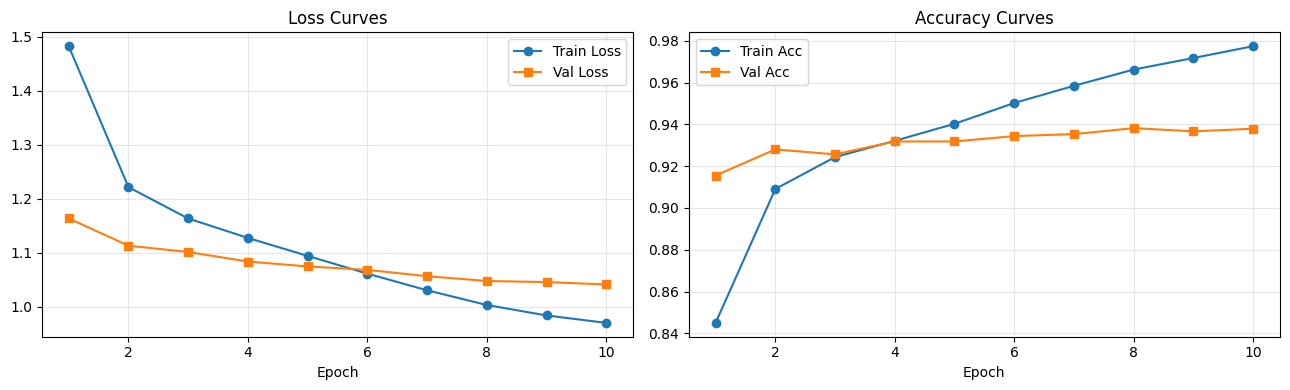

In [10]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs, history["val_loss"], marker="s", label="Val Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["train_acc"], marker="o", label="Train Acc")
axes[1].plot(epochs, history["val_acc"], marker="s", label="Val Acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluate final model on official test split

In [11]:
head_preds, head_labels = evaluate_head(
    head=head,
    loader=test_loader,
    hf_model_name=HF_CLIP_MODEL,
    device=DEVICE,
)

final_metrics = classification_metrics(head_labels, head_preds)
print(final_metrics)

print("\n=== Classification Report ===")
print(full_classification_report(head_labels, head_preds, CLASSES))

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 9844.91it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Evaluating head: 100%|██████████| 710/710 [02:12<00:00,  5.37it/s]

{'accuracy': 0.9381493220637436, 'macro_f1': 0.9377992207893}

=== Classification Report ===
                         precision    recall  f1-score   support

              apple_pie     0.9478    0.9316    0.9397       234
         baby_back_ribs     0.9643    0.9774    0.9708       221
                baklava     0.9333    0.9912    0.9614       226
         beef_carpaccio     0.8462    0.8919    0.8684       222
           beef_tartare     0.7322    0.7778    0.7543       225
             beet_salad     0.9471    0.9598    0.9534       224
               beignets     0.9457    0.9330    0.9393       224
               bibimbap     0.9860    0.9422    0.9636       225
          bread_pudding     0.9735    0.9735    0.9735       226
      breakfast_burrito     0.9336    0.9206    0.9271       214
             bruschetta     0.9404    0.9567    0.9485       231
           caesar_salad     0.9736    0.9736    0.9736       227
                cannoli     0.9440    0.9522    0.9481       

## 8. Compare all methods

In [12]:
results_df = build_results_table(
    zero_shot_metrics=zs_metrics,
    few_shot_results=few_shot_results,
    final_model_metrics=final_metrics,
)
results_df

,Method,Accuracy,Macro-F1
0,"Zero-Shot CLIP (multimodal, α=0.50)",0.829635,0.833675
1,Few-Shot CLIP K=1 + LogReg,0.573120,0.553772
2,Few-Shot CLIP K=5 + LogReg,0.804763,0.809499
3,Few-Shot CLIP K=10 + LogReg,0.851690,0.853667
4,Fine-tuned Multimodal Head,0.938149,0.937799


In [13]:
confusions = top_confused_pairs(head_labels, head_preds, CLASSES, top_n=15)
confusions

,Count,True Class,Predicted As
0,15,tuna_tartare,beef_tartare
1,11,sushi,sashimi
2,11,beef_tartare,tuna_tartare
3,9,beef_tartare,beef_carpaccio
4,8,foie_gras,beef_tartare
5,8,edamame,hummus
6,7,tuna_tartare,sashimi
7,7,cup_cakes,red_velvet_cake
8,6,sashimi,sushi
9,6,ice_cream,frozen_yogurt
